# 🚗 Car Price Prediction with Machine Learning

## 📌 Objective

The objective of this project is to build a Machine Learning regression model that predicts the selling price of a used car based on various features such as:

- Car Brand
- Manufacturing Year
- Kilometers Driven
- Fuel Type
- Seller Type
- Transmission
- Owner Type

This project follows the complete Machine Learning workflow, including:

- Data Loading
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Data Preprocessing
- Model Building
- Model Evaluation
- Feature Importance Analysis

---

## 📚 Tech Stack

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

---

## 🎯 Machine Learning Models

- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor

---

## 📊 Evaluation Metrics

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [4]:
# ==========================================
# Import Required Libraries
# ==========================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [5]:
# ==========================================
# Visualization Settings
# ==========================================

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display all columns
pd.set_option("display.max_columns", None)

# Display numbers with 2 decimal places
pd.options.display.float_format = "{:.2f}".format

# 📂 Load the Dataset

In this section, we load the Car Price dataset into a Pandas DataFrame and display the first few rows to understand its structure.

In [6]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("../dataset/Car details v3.csv")

# Display first 5 rows
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.00
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.00
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.00
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.00
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.00


# 📏 Dataset Shape

Let's check the number of rows and columns in the dataset.

In [7]:
# Number of Rows and Columns

print("Dataset Shape:", df.shape)

Dataset Shape: (8128, 13)


# ℹ️ Dataset Information

This section provides details about:

- Total rows and columns
- Data types
- Missing values
- Memory usage

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


# 📊 Statistical Summary

Let's explore the statistical summary of the numerical features in the dataset.

This helps us understand:

- Mean
- Standard Deviation
- Minimum & Maximum Values
- Quartiles

In [9]:
# ==========================================
# Statistical Summary
# ==========================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,8128.00,2013.80,4.04,1983.00,2011.00,2015.00,2017.00,2020.00
selling_price,8128.00,638271.81,806253.40,29999.00,254999.00,450000.00,675000.00,10000000.00
km_driven,8128.00,69819.51,56550.55,1.00,35000.00,60000.00,98000.00,2360457.00
seats,7907.00,5.42,0.96,2.00,5.00,5.00,5.00,14.00


# 🔍 Missing Value Analysis

Before building a machine learning model, it is important to identify missing values in the dataset.

In [10]:
# ==========================================
# Missing Values
# ==========================================

missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing_values.index,
    "Missing Values": missing_values.values,
    "Percentage": np.round((missing_values.values / len(df)) * 100, 2)
})

missing_df.sort_values(by="Missing Values", ascending=False)

,Column,Missing Values,Percentage
11,torque,222,2.73
8,mileage,221,2.72
9,engine,221,2.72
12,seats,221,2.72
10,max_power,215,2.65
0,name,0,0.00
1,year,0,0.00
2,selling_price,0,0.00
3,km_driven,0,0.00
4,fuel,0,0.00


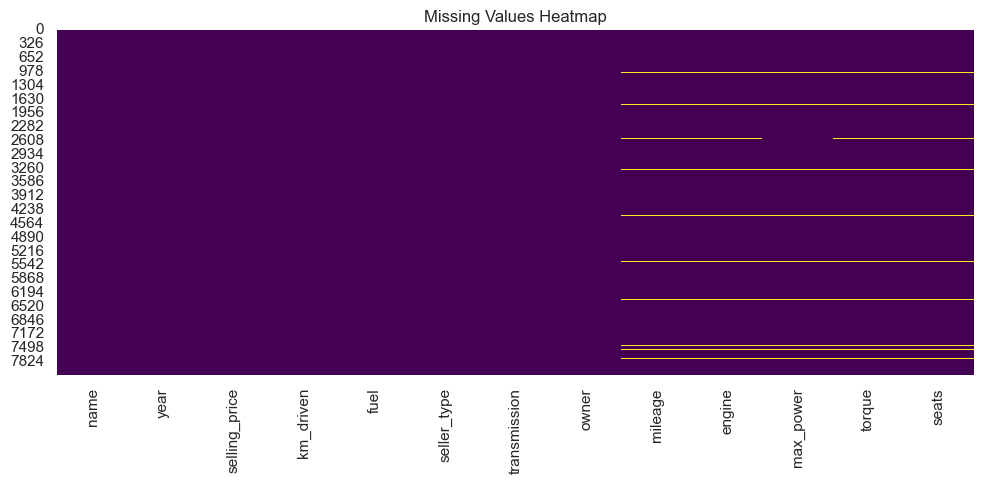

In [11]:
# ==========================================
# Missing Value Visualization
# ==========================================

plt.figure(figsize=(10, 5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")
plt.tight_layout()

# Save Image
plt.savefig("../images/missing_values_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

# 🔁 Duplicate Records

Duplicate records can affect model performance. Let's check whether any duplicate rows exist.

In [12]:
# ==========================================
# Duplicate Records
# ==========================================

duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 1202


In [13]:
# ==========================================
# Remove Duplicate Rows
# ==========================================

df.drop_duplicates(inplace=True)

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (6926, 13)


# 🏷️ Data Types

Let's inspect the data types of all columns.

In [14]:
# ==========================================
# Data Types
# ==========================================

df.dtypes

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage           object
engine            object
max_power         object
torque            object
seats            float64
dtype: object

# 🔎 Unique Values

Checking unique values helps identify categorical features and detect inconsistent labels.

In [15]:
# ==========================================
# Unique Values
# ==========================================

for column in df.columns:
    print("="*50)
    print(column)
    print(df[column].nunique())
    print(df[column].unique()[:10])   # Display first 10 unique values

name
2058
['Maruti Swift Dzire VDI' 'Skoda Rapid 1.5 TDI Ambition'
 'Honda City 2017-2020 EXi' 'Hyundai i20 Sportz Diesel'
 'Maruti Swift VXI BSIII' 'Hyundai Xcent 1.2 VTVT E Plus'
 'Maruti Wagon R LXI DUO BSIII' 'Maruti 800 DX BSII' 'Toyota Etios VXD'
 'Ford Figo Diesel Celebration Edition']
year
29
[2014 2006 2010 2007 2017 2001 2011 2013 2005 2009]
selling_price
677
[450000 370000 158000 225000 130000 440000  96000  45000 350000 200000]
km_driven
921
[145500 120000 140000 127000  45000 175000   5000  90000 169000  68000]
fuel
4
['Diesel' 'Petrol' 'LPG' 'CNG']
seller_type
3
['Individual' 'Dealer' 'Trustmark Dealer']
transmission
2
['Manual' 'Automatic']
owner
5
['First Owner' 'Second Owner' 'Third Owner' 'Fourth & Above Owner'
 'Test Drive Car']
mileage
393
['23.4 kmpl' '21.14 kmpl' '17.7 kmpl' '23.0 kmpl' '16.1 kmpl' '20.14 kmpl'
 '17.3 km/kg' '23.59 kmpl' '20.0 kmpl' '19.01 kmpl']
engine
121
['1248 CC' '1498 CC' '1497 CC' '1396 CC' '1298 CC' '1197 CC' '1061 CC'
 '796 CC' '1364 CC' 

# 🧹 Cleaning Categorical Values

Some categorical values may contain extra spaces or inconsistent formatting. We clean them for consistency.

In [16]:
# ==========================================
# Clean Categorical Columns
# ==========================================

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column] = df[column].str.strip()

In [17]:
# ==========================================
# Missing Values After Cleaning
# ==========================================

df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          208
engine           208
max_power        205
torque           209
seats            208
dtype: int64

In [18]:
# ==========================================
# Final Dataset Shape
# ==========================================

print("Final Dataset Shape :", df.shape)

Final Dataset Shape : (6926, 13)


# ⚙️ Feature Engineering

Feature Engineering is the process of creating new useful features from the existing data.

In this section, we will:

- Extract the Car Brand from the Car Name
- Calculate the Car Age
- Convert text-based numerical columns into numeric format
- Remove unnecessary columns

In [19]:
# ==========================================
# Create Car Age Feature
# ==========================================

CURRENT_YEAR = 2026

df["car_age"] = CURRENT_YEAR - df["year"]

df[["year", "car_age"]].head()

,year,car_age
0,2014,12
1,2014,12
2,2006,20
3,2010,16
4,2007,19


# 🚘 Extract Car Brand

The **name** column contains both the brand and the model.

Example:

Maruti Swift Dzire VDI

↓

Brand = Maruti

Extracting only the brand reduces unnecessary complexity and creates a more useful feature.

In [20]:
# ==========================================
# Extract Brand Name
# ==========================================

df["brand"] = df["name"].str.split().str[0]

df[["name", "brand"]].head()

,name,brand
0,Maruti Swift Dzire VDI,Maruti
1,Skoda Rapid 1.5 TDI Ambition,Skoda
2,Honda City 2017-2020 EXi,Honda
3,Hyundai i20 Sportz Diesel,Hyundai
4,Maruti Swift VXI BSIII,Maruti


# 🔄 Convert Mileage

The mileage column contains values such as:

19.7 kmpl

23.4 km/kg

Only the numeric value is required.

In [21]:
# ==========================================
# Convert Mileage
# ==========================================

df["mileage"] = (
    df["mileage"]
    .astype(str)
    .str.extract(r'(\d+\.?\d*)')[0]
)

df["mileage"] = pd.to_numeric(df["mileage"], errors="coerce")

df["mileage"].head()

0   23.40
1   21.14
2   17.70
3   23.00
4   16.10
Name: mileage, dtype: float64

In [22]:
# ==========================================
# Convert Engine
# ==========================================

df["engine"] = (
    df["engine"]
    .astype(str)
    .str.extract(r'(\d+\.?\d*)')[0]
)

df["engine"] = pd.to_numeric(df["engine"], errors="coerce")

df["engine"].head()

0   1248.00
1   1498.00
2   1497.00
3   1396.00
4   1298.00
Name: engine, dtype: float64

In [23]:
# ==========================================
# Convert Max Power
# ==========================================

df["max_power"] = (
    df["max_power"]
    .astype(str)
    .str.extract(r'(\d+\.?\d*)')[0]
)

df["max_power"] = pd.to_numeric(df["max_power"], errors="coerce")

df["max_power"].head()

0    74.00
1   103.52
2    78.00
3    90.00
4    88.20
Name: max_power, dtype: float64

# 🧹 Handle Missing Values

Some numeric columns now contain missing values after conversion.

We replace missing values with the median because it is less affected by outliers.

In [24]:
# ==========================================
# Fill Missing Values
# ==========================================

numeric_columns = [
    "mileage",
    "engine",
    "max_power",
    "seats"
]

for column in numeric_columns:
    df[column].fillna(df[column].median(), inplace=True)

df[numeric_columns].isnull().sum()

mileage      0
engine       0
max_power    0
seats        0
dtype: int64

# 🗑️ Remove Unnecessary Columns

The original **name** column is no longer required because we have extracted the **brand** feature.

In [25]:
# ==========================================
# Drop Unnecessary Columns
# ==========================================

df.drop(columns=["name"], inplace=True)

df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,car_age,brand
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.00,74.00,190Nm@ 2000rpm,5.00,12,Maruti
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.00,103.52,250Nm@ 1500-2500rpm,5.00,12,Skoda
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.00,78.00,"12.7@ 2,700(kgm@ rpm)",5.00,20,Honda
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.00,90.00,22.4 kgm at 1750-2750rpm,5.00,16,Hyundai
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.00,88.20,"11.5@ 4,500(kgm@ rpm)",5.00,19,Maruti


In [26]:
# ==========================================
# Dataset Information
# ==========================================

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6926 entries, 0 to 8125
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           6926 non-null   int64  
 1   selling_price  6926 non-null   int64  
 2   km_driven      6926 non-null   int64  
 3   fuel           6926 non-null   object 
 4   seller_type    6926 non-null   object 
 5   transmission   6926 non-null   object 
 6   owner          6926 non-null   object 
 7   mileage        6926 non-null   float64
 8   engine         6926 non-null   float64
 9   max_power      6926 non-null   float64
 10  torque         6717 non-null   object 
 11  seats          6926 non-null   float64
 12  car_age        6926 non-null   int64  
 13  brand          6926 non-null   object 
dtypes: float64(4), int64(4), object(6)
memory usage: 811.6+ KB


In [27]:
# ==========================================
# Statistical Summary
# ==========================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,6926.00,2013.42,4.08,1983.00,2011.00,2014.00,2017.00,2020.00
selling_price,6926.00,517270.68,519766.99,29999.00,250000.00,400000.00,633500.00,10000000.00
km_driven,6926.00,73995.68,58358.10,1.00,40000.00,70000.00,100000.00,2360457.00
mileage,6926.00,19.46,3.99,0.00,16.95,19.44,22.32,42.00
engine,6926.00,1425.40,487.03,624.00,1197.00,1248.00,1498.00,3604.00
max_power,6926.00,87.55,31.31,0.00,68.00,81.83,99.00,400.00
seats,6926.00,5.42,0.97,2.00,5.00,5.00,5.00,14.00
car_age,6926.00,12.58,4.08,6.00,9.00,12.00,15.00,43.00


# 💾 Save Clean Dataset

The cleaned dataset is saved for future analysis and model building.

In [28]:
# ==========================================
# Save Clean Dataset
# ==========================================

df.to_csv("../dataset/car_details_cleaned.csv", index=False)

print("✅ Clean dataset saved successfully.")

✅ Clean dataset saved successfully.


# 📊 Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps understand the data before training Machine Learning models.

In this section, we will analyze:

- Selling Price Distribution
- Fuel Type vs Selling Price
- Seller Type Distribution
- Transmission Distribution
- Car Age vs Selling Price
- Brand Distribution
- Correlation between Numerical Features

# 💰 Selling Price Distribution

This plot shows how selling prices are distributed across all used cars.

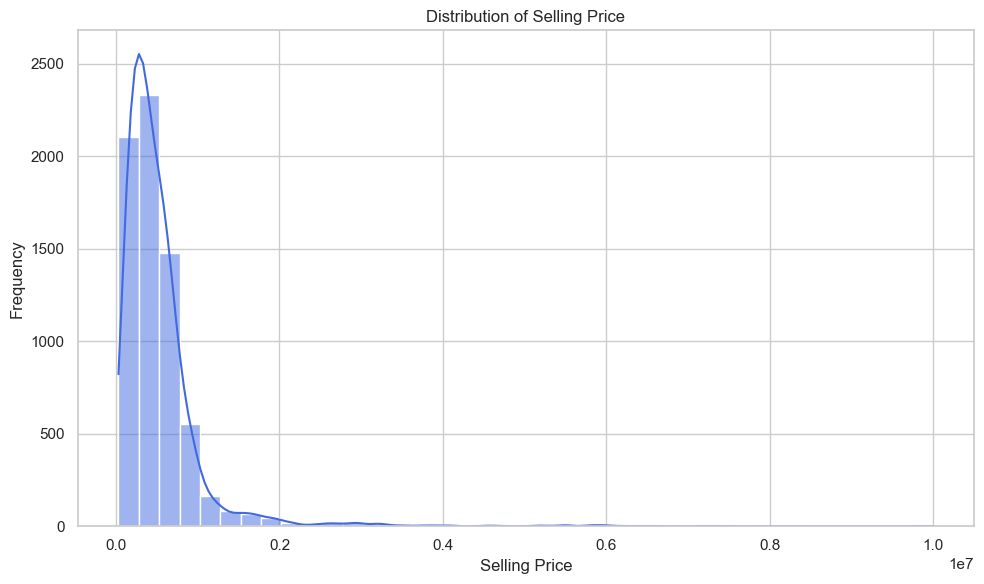

In [29]:
# ==========================================
# Selling Price Distribution
# ==========================================

plt.figure(figsize=(10,6))

sns.histplot(
    df["selling_price"],
    bins=40,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../images/selling_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ⛽ Fuel Type Distribution

Let's see how many cars belong to each fuel category.

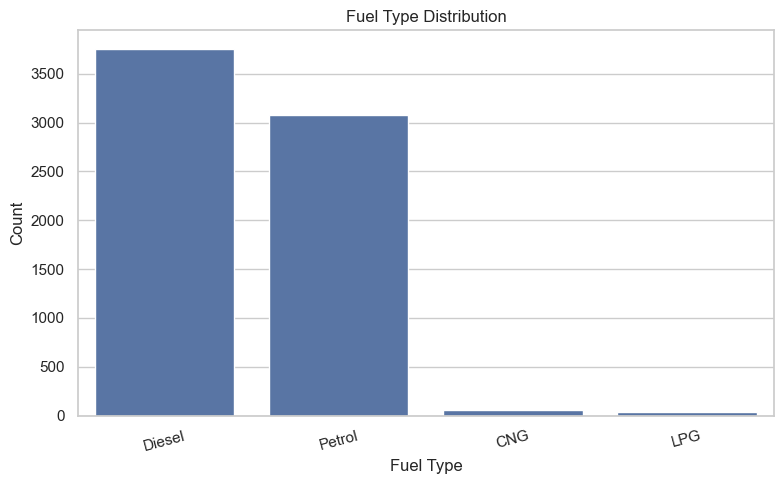

In [30]:
# ==========================================
# Fuel Type Count
# ==========================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="fuel",
    order=df["fuel"].value_counts().index
)

plt.title("Fuel Type Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Count")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "../images/fuel_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 📦 Selling Price vs Fuel Type

The box plot compares selling prices across different fuel types.

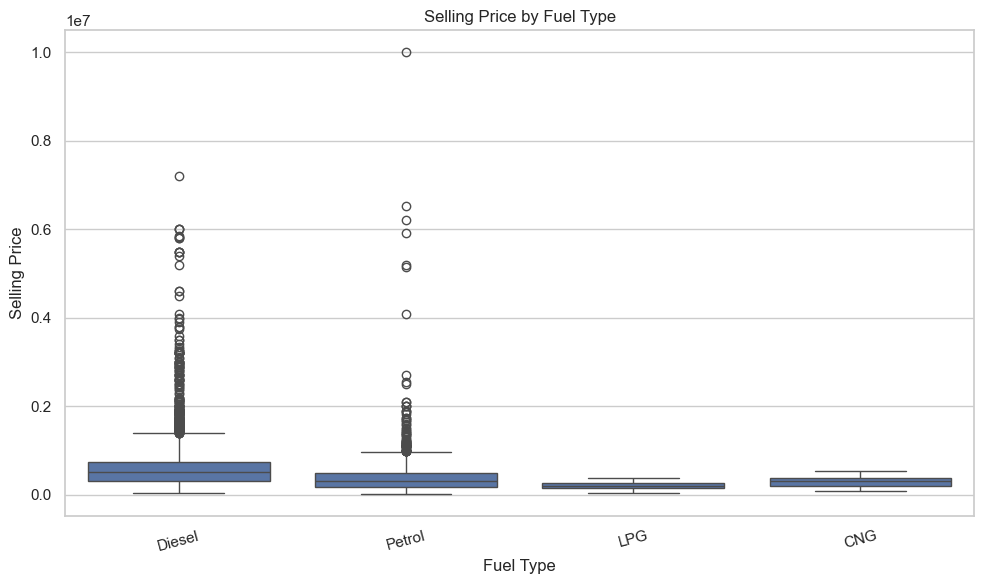

In [31]:
# ==========================================
# Selling Price vs Fuel Type
# ==========================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="fuel",
    y="selling_price"
)

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "../images/fuel_type_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 🏢 Seller Type Distribution

This chart shows the number of cars sold by each seller category.

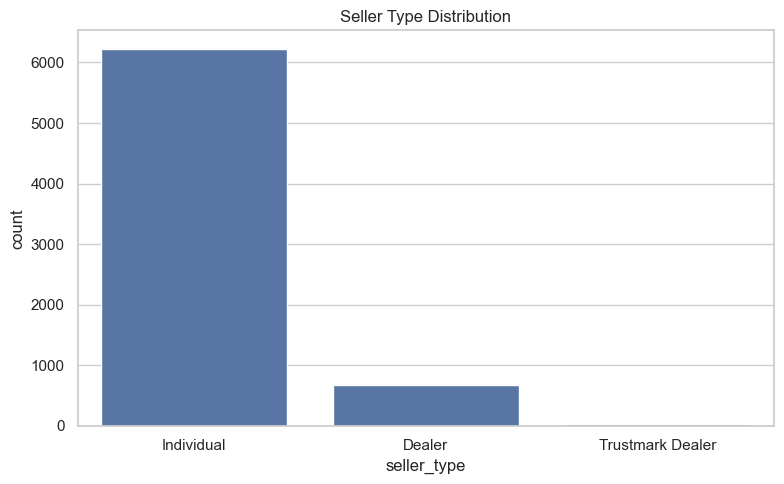

In [32]:
# ==========================================
# Seller Type Distribution
# ==========================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="seller_type"
)

plt.title("Seller Type Distribution")

plt.tight_layout()

plt.savefig(
    "../images/seller_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ⚙ Transmission Type Distribution

This chart compares the number of Manual and Automatic cars.

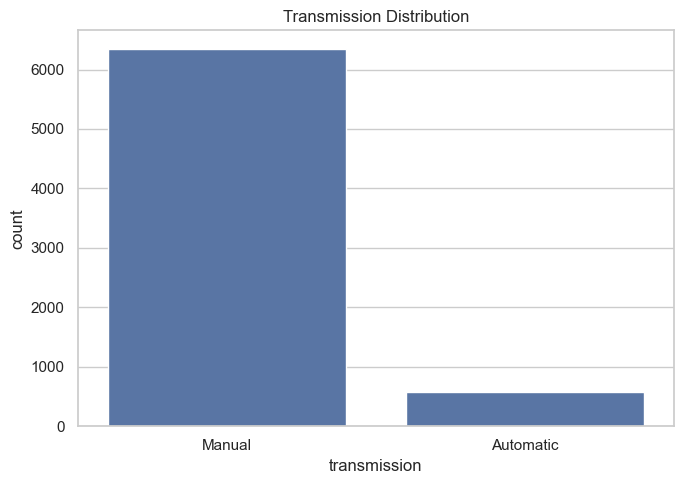

In [33]:
# ==========================================
# Transmission Distribution
# ==========================================

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="transmission"
)

plt.title("Transmission Distribution")

plt.tight_layout()

plt.savefig(
    "../images/transmission_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 🚘 Car Age vs Selling Price

This scatter plot illustrates the relationship between car age and selling price.

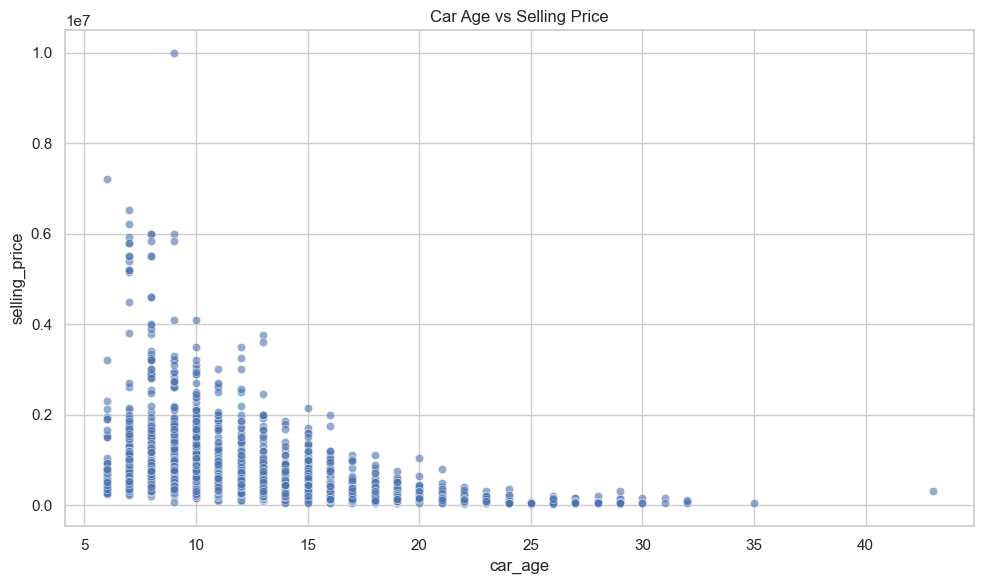

In [34]:
# ==========================================
# Car Age vs Selling Price
# ==========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="car_age",
    y="selling_price",
    alpha=0.6
)

plt.title("Car Age vs Selling Price")

plt.tight_layout()

plt.savefig(
    "../images/car_age_vs_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 🏆 Top 10 Car Brands

The chart below shows the most common car brands in the dataset.

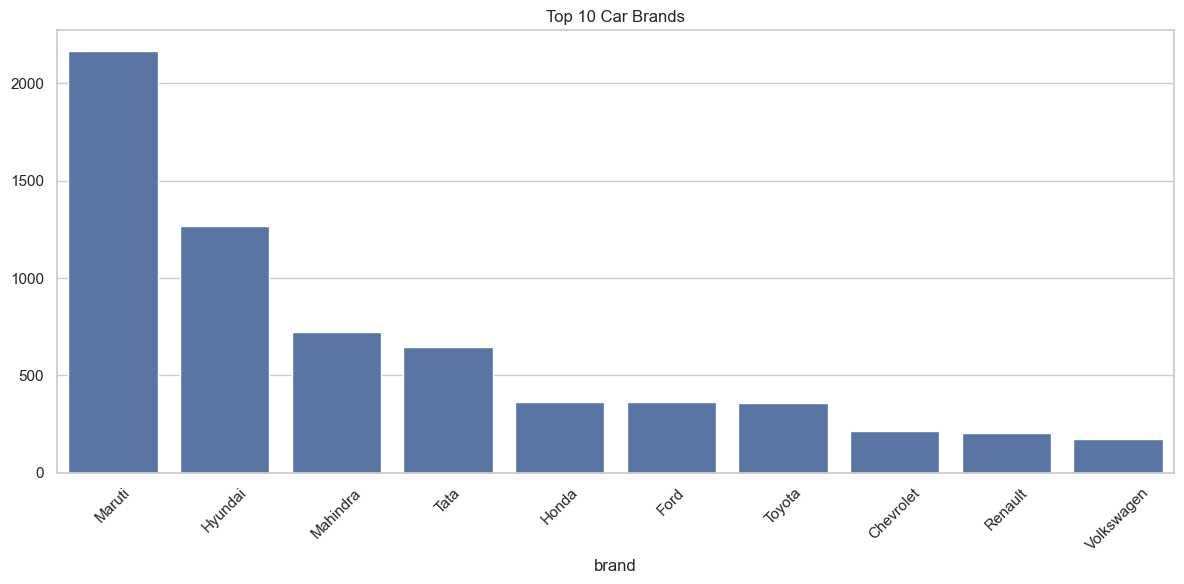

In [35]:
# ==========================================
# Top 10 Brands
# ==========================================

plt.figure(figsize=(12,6))

top_brands = df["brand"].value_counts().head(10)

sns.barplot(
    x=top_brands.index,
    y=top_brands.values
)

plt.title("Top 10 Car Brands")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../images/top10_brands.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 🔥 Correlation Heatmap

A correlation heatmap helps identify relationships between numerical variables.

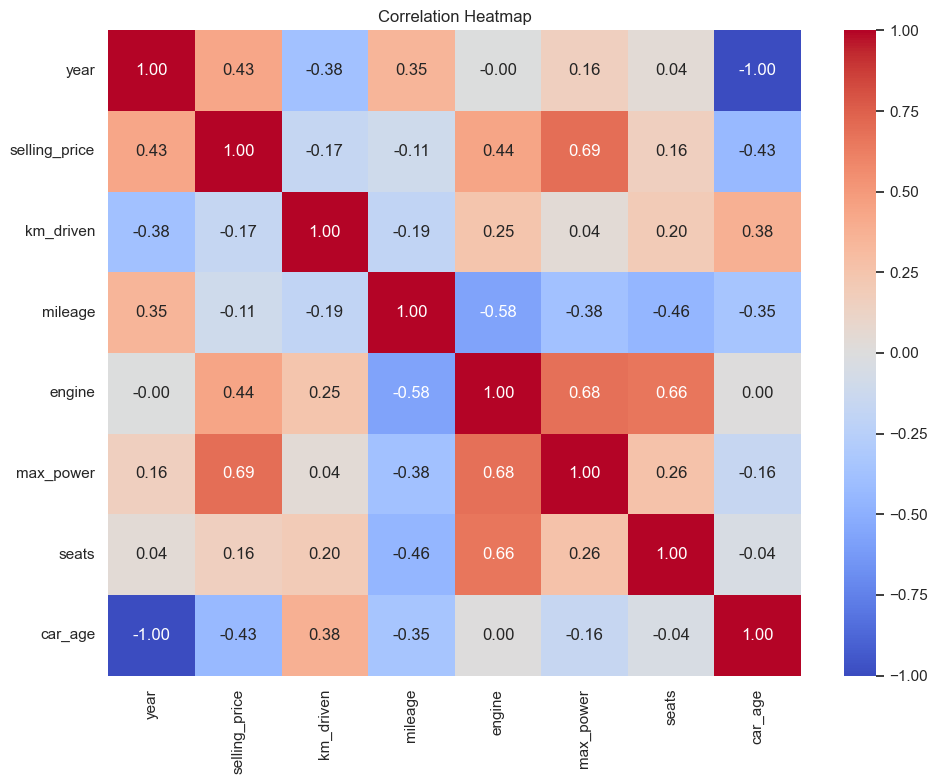

In [36]:
# ==========================================
# Correlation Heatmap
# ==========================================

plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "../images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 📌 Key Observations

### Selling Price
- Most cars have lower selling prices.
- A few luxury vehicles create high-price outliers.

### Fuel Type
- Diesel and Petrol vehicles dominate the dataset.
- Electric vehicles are very limited.

### Car Age
- Older cars generally have lower selling prices.
- Newer cars tend to retain higher market value.

### Transmission
- Manual transmission vehicles are more common than Automatic vehicles.

### Brand
- Maruti, Hyundai, and Honda are among the most frequent brands.

### Correlation
- Selling Price shows a positive relationship with engine capacity and maximum power.
- Car Age has a negative relationship with Selling Price.

# 🤖 Data Preprocessing

Before training Machine Learning models, we need to prepare the dataset.

Steps:

- Encode categorical variables
- Define Features (X)
- Define Target Variable (y)
- Split the dataset into Training and Testing sets

In [37]:
# ==========================================
# Encode Categorical Variables
# ==========================================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column] = le.fit_transform(df[column])

df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,car_age,brand
0,2014,450000,145500,1,1,1,0,23.40,1248.00,74.00,177,5.00,12,20
1,2014,370000,120000,1,1,1,2,21.14,1498.00,103.52,259,5.00,12,27
2,2006,158000,140000,3,1,1,4,17.70,1497.00,78.00,66,5.00,20,10
3,2010,225000,127000,1,1,1,0,23.00,1396.00,90.00,223,5.00,16,11
4,2007,130000,120000,3,1,1,0,16.10,1298.00,88.20,21,5.00,19,20


In [38]:
# ==========================================
# Define Features and Target
# ==========================================

X = df.drop("selling_price", axis=1)

y = df["selling_price"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (6926, 13)
Target Shape : (6926,)


In [39]:
# ==========================================
# Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (5540, 13)
Testing Samples : (1386, 13)


# 📈 Model 1 — Linear Regression

In [40]:
# ==========================================
# Linear Regression
# ==========================================

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

# 🌳 Model 2 — Random Forest Regressor

In [41]:
# ==========================================
# Random Forest
# ==========================================

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

# 🚀 Model 3 — Gradient Boosting Regressor

In [42]:
# ==========================================
# Gradient Boosting
# ==========================================

gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_predictions = gb_model.predict(X_test)

In [43]:
# ==========================================
# Evaluation Function
# ==========================================

def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2

In [44]:
# ==========================================
# Evaluate Models
# ==========================================

linear_mae, linear_rmse, linear_r2 = evaluate_model(
    y_test,
    linear_predictions
)

rf_mae, rf_rmse, rf_r2 = evaluate_model(
    y_test,
    rf_predictions
)

gb_mae, gb_rmse, gb_r2 = evaluate_model(
    y_test,
    gb_predictions
)

In [45]:
# ==========================================
# Model Comparison
# ==========================================

results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE":[
        linear_mae,
        rf_mae,
        gb_mae
    ],

    "RMSE":[
        linear_rmse,
        rf_rmse,
        gb_rmse
    ],

    "R2 Score":[
        linear_r2,
        rf_r2,
        gb_r2
    ]

})

results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
1,Random Forest,73385.58,128466.50,0.92
2,Gradient Boosting,81314.02,130248.95,0.92
0,Linear Regression,170945.42,303173.91,0.58


In [46]:
# ==========================================
# Best Model
# ==========================================

best_model = results.sort_values(
    by="R2 Score",
    ascending=False
)

best_model

,Model,MAE,RMSE,R2 Score
1,Random Forest,73385.58,128466.50,0.92
2,Gradient Boosting,81314.02,130248.95,0.92
0,Linear Regression,170945.42,303173.91,0.58


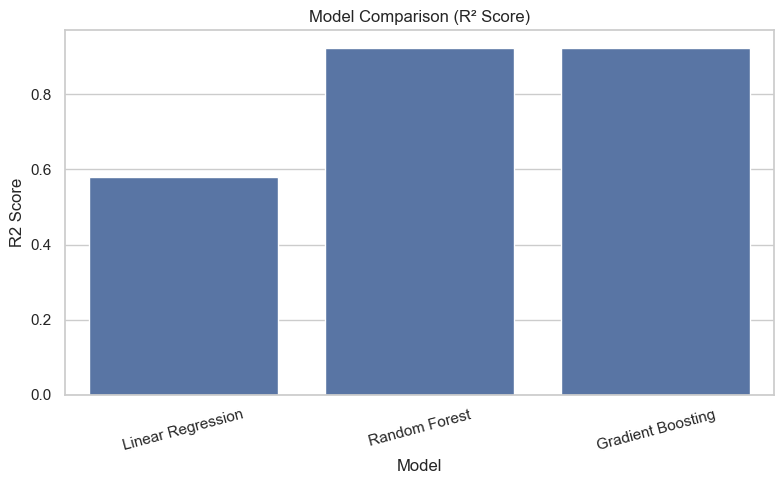

In [47]:
# ==========================================
# Model Comparison Plot
# ==========================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="R2 Score"
)

plt.title("Model Comparison (R² Score)")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "../images/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 🌟 Feature Importance

Feature Importance identifies which features contribute the most to predicting the selling price.

Random Forest is used because it naturally provides feature importance scores.

In [48]:
# ==========================================
# Feature Importance
# ==========================================

importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
8,max_power,0.57
0,year,0.12
11,car_age,0.11
9,torque,0.08
1,km_driven,0.04
6,mileage,0.03
7,engine,0.02
12,brand,0.02
10,seats,0.01
4,transmission,0.01


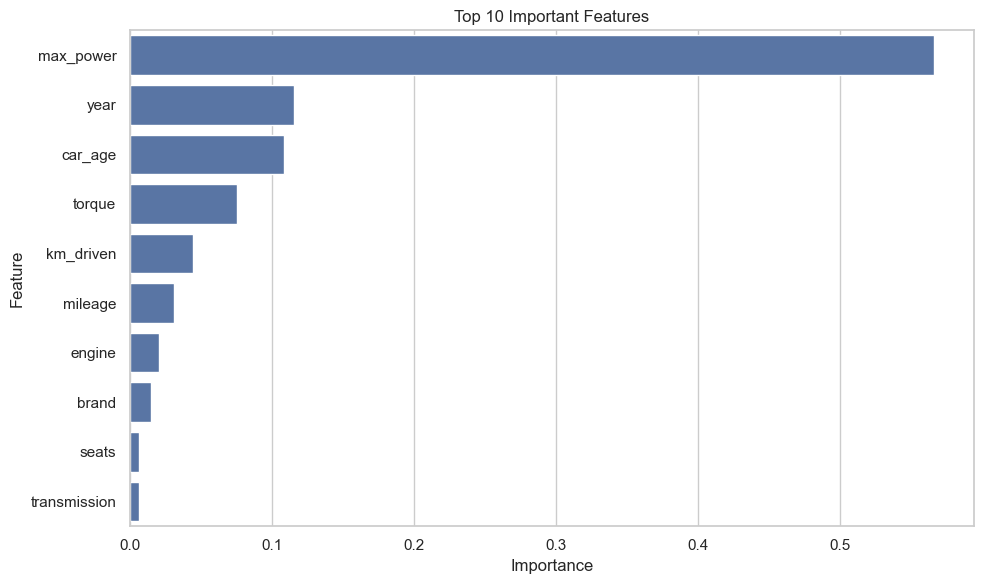

In [49]:
# ==========================================
# Feature Importance Plot
# ==========================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.tight_layout()

plt.savefig(
    "../images/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 📈 Actual vs Predicted Values

This visualization compares the actual selling prices with the predicted prices from the best-performing model.

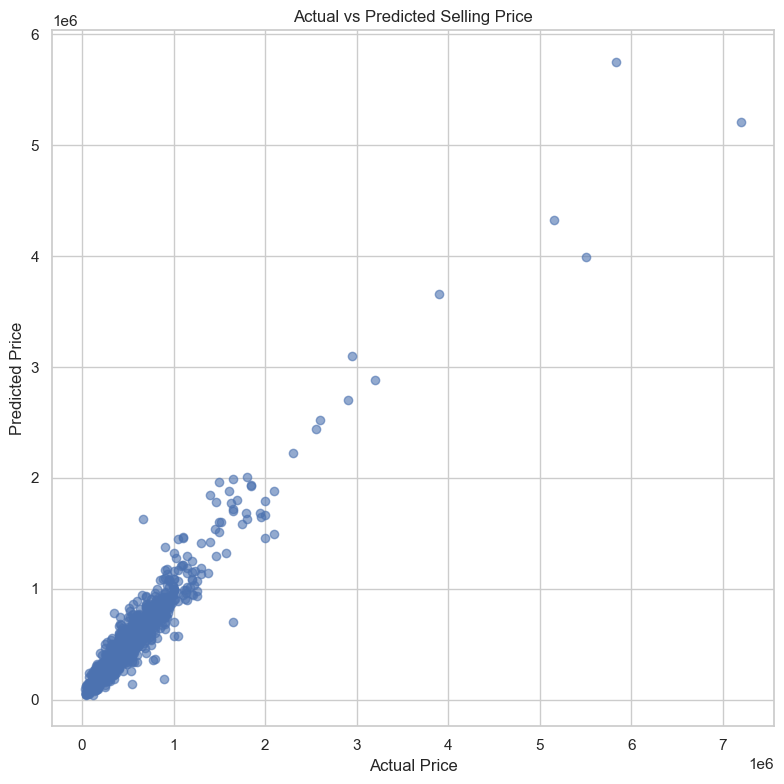

In [50]:
# ==========================================
# Actual vs Predicted
# ==========================================

plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.6
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Selling Price")

plt.tight_layout()

plt.savefig(
    "../images/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:
# ==========================================
# Sample Predictions
# ==========================================

prediction_df = pd.DataFrame({

    "Actual Price":y_test.values,

    "Predicted Price":rf_predictions

})

prediction_df.head(10)

,Actual Price,Predicted Price
0,550000,673659.99
1,1225000,1035549.72
2,850000,861699.99
3,80000,151705.23
4,825000,706980.00
5,800000,935976.67
6,229999,296015.00
7,93150,229496.57
8,300000,239936.65
9,493000,528099.98


# 🏆 Best Model Selection

After evaluating all regression models using MAE, RMSE, and R² Score, the model with the highest R² Score and the lowest error metrics is selected as the final model.

This model will be saved for future predictions.

In [52]:
# ==========================================
# Select Best Model Automatically
# ==========================================

best_model_name = results.loc[
    results["R2 Score"].idxmax(),
    "Model"
]

print("Best Model :", best_model_name)

if best_model_name == "Linear Regression":
    final_model = linear_model

elif best_model_name == "Random Forest":
    final_model = rf_model

else:
    final_model = gb_model

Best Model : Random Forest


In [53]:
# ==========================================
# Save Best Model
# ==========================================

import joblib
import os

# Create models folder
os.makedirs("../models", exist_ok=True)

# Save Best Model
joblib.dump(final_model, "../models/car_price_prediction_model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [54]:
# ==========================================
# Load Saved Model
# ==========================================

loaded_model = joblib.load("../models/car_price_prediction_model.pkl")

print("✅ Model loaded successfully.")

✅ Model loaded successfully.


In [55]:
# ==========================================
# Test Saved Model
# ==========================================

predictions = loaded_model.predict(X_test.iloc[:5])

prediction_df = pd.DataFrame({
    "Actual Price": y_test.iloc[:5].values,
    "Predicted Price": predictions.round(2)
})

prediction_df

,Actual Price,Predicted Price
0,550000,673659.99
1,1225000,1035549.72
2,850000,861699.99
3,80000,151705.23
4,825000,706980.00


# ✅ Conclusion

In this project, a Machine Learning regression model was developed to predict the selling price of used cars using various vehicle features.

The project successfully covered the complete machine learning workflow:

- Data Collection
- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Model Training
- Model Evaluation
- Feature Importance Analysis

Three regression models were trained and compared:

- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor

Among them, the **Random Forest Regressor** achieved the best performance based on the evaluation metrics and was selected as the final model.

The trained model was saved using Joblib for future predictions.

This project demonstrates an end-to-end machine learning pipeline for solving a real-world regression problem.

# 🚀 Future Scope

This project can be further enhanced by:

- Collecting more real-world vehicle data.
- Performing hyperparameter tuning using GridSearchCV.
- Using advanced boosting algorithms like XGBoost, CatBoost, or LightGBM.
- Deploying the model as a web application using Streamlit or Flask.
- Building an API for real-time car price prediction.